#EDA

In [ ]:
import pandas as pd
import re
from google.colab import drive
from google.colab import files

# 1. KẾT NỐI DRIVE VÀ ĐỌC FILE GỐC
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/ĐỒ ÁN CUỐI KỲ_NLP_NHOM6/Source code/Data ABSA.csv'
df = pd.read_csv(file_path, encoding='utf-8')
print(f"✅ Đã đọc file thành công! Tổng số dòng gốc: {len(df)}")

# 2. Định nghĩa các khía cạnh và cảm xúc cần thống kê
aspects = ['Vị trí', 'Dịch vụ', 'Giá cả', 'Cơ sở vật chất', 'Vệ sinh']
sentiments = ['Tích cực', 'Trung lập', 'Tiêu cực']

# 3. Khởi tạo bảng đếm (Dictionary)
# Cấu trúc: { 'Vị trí': {'Tích cực': 0, 'Trung lập': 0, 'Tiêu cực': 0}, ... }
stats_dict = {a: {s: 0 for s in sentiments} for a in aspects}

# 4. Duyệt qua từng dòng để đếm
for label_str in df['Label'].astype(str):
    # Tìm tất cả các cụm {Khía cạnh#Cảm xúc}
    found = re.findall(r'\{(.*?)\}', label_str)
    for item in found:
        parts = item.split('#')
        if len(parts) == 2:
            a_part = parts[0].strip()
            s_part = parts[1].strip()

            # Nếu khớp với danh mục thì tăng biến đếm
            if a_part in stats_dict and s_part in sentiments:
                stats_dict[a_part][s_part] += 1

# 5. Chuyển kết quả sang DataFrame để hiển thị bảng đẹp mắt
df_report = pd.DataFrame.from_dict(stats_dict, orient='index').reset_index()
df_report.columns = ['Khía cạnh', 'Tích cực', 'Trung lập', 'Tiêu cực']

# Tính tổng cộng cho mỗi khía cạnh
df_report['Tổng cộng'] = df_report['Tích cực'] + df_report['Trung lập'] + df_report['Tiêu cực']

# 6. Hiển thị kết quả
print("--- BẢNG THỐNG KÊ KẾT QUẢ GÁN NHÃN ---")
print(df_report.to_markdown(index=False))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Đã đọc file thành công! Tổng số dòng gốc: 6357
--- BẢNG THỐNG KÊ KẾT QUẢ GÁN NHÃN ---
| Khía cạnh      |   Tích cực |   Trung lập |   Tiêu cực |   Tổng cộng |
|:---------------|-----------:|------------:|-----------:|------------:|
| Vị trí         |       3119 |         694 |        111 |        3924 |
| Dịch vụ        |       3414 |           0 |        821 |        4235 |
| Giá cả         |       1113 |         488 |        319 |        1920 |
| Cơ sở vật chất |       2351 |         752 |       1295 |        4398 |
| Vệ sinh        |       2164 |        1365 |        373 |        3902 |


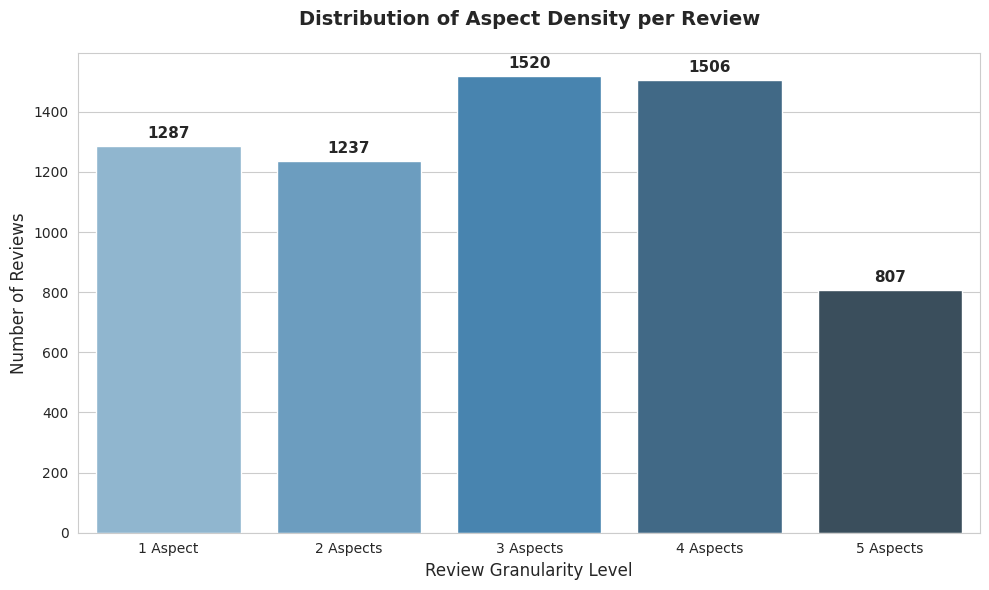

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 1. Xử lý dữ liệu: Đếm số lượng khía cạnh trong mỗi câu
def count_aspects(label_str):
    if pd.isna(label_str) or label_str == "":
        return 0
    found = re.findall(r'\{(.*?)\}', str(label_str))
    return len(found)

# Tạo một cột tạm để giữ số lượng khía cạnh
df['Aspect_Count'] = df['Label'].apply(count_aspects)

# Lọc bỏ các dòng có 0 khía cạnh (nếu có) để biểu đồ tập trung vào dữ liệu đã gán nhãn
df_plot_1 = df[df['Aspect_Count'] > 0].copy()

# 2. Chuẩn bị bảng tần suất
dist_data = df_plot_1['Aspect_Count'].value_counts().sort_index().reset_index()
dist_data.columns = ['So_Luong', 'Counts']

# Chuyển đổi con số thành nhãn chữ rõ ràng
dist_data['Labels'] = dist_data['So_Luong'].apply(lambda x: f"{x} Aspect" if x == 1 else f"{x} Aspects")

# 3. Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Vẽ thanh bar
ax = sns.barplot(
    data=dist_data,
    x='Labels',
    y='Counts',
    palette='Blues_d',
    hue='Labels',
    legend=False
)

# Thêm tiêu đề và nhãn trục
plt.title('Distribution of Aspect Density per Review', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Review Granularity Level', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)

# Thêm số liệu cụ thể trên đầu mỗi cột
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=11,
                fontweight='bold')

plt.tight_layout()
plt.show()

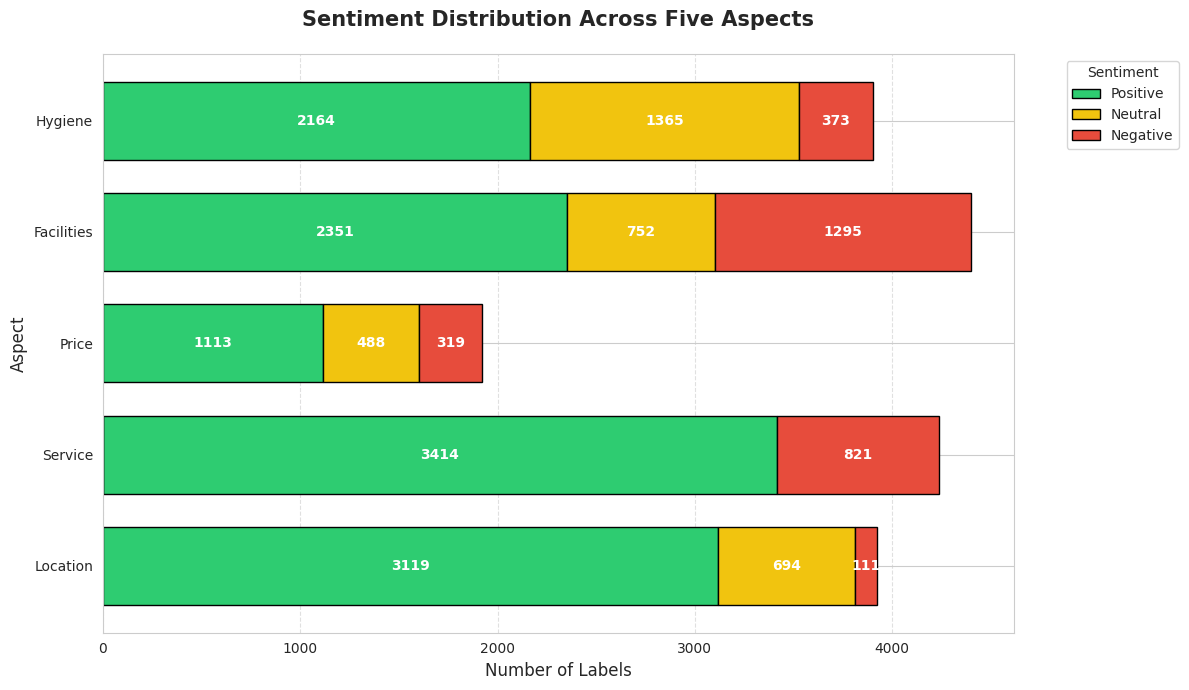

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if 'Khía cạnh' in df_report.columns:
    df_report = df_report.set_index('Khía cạnh')

# 2. Vẽ Stacked Bar Chart
# Lưu ý: Chúng ta chỉ lấy 3 cột cảm xúc để vẽ, Index (tên khía cạnh) tự động làm nhãn trục Y
ax = df_report[['Tích cực', 'Trung lập', 'Tiêu cực']].plot(
    kind='barh',
    stacked=True,
    figsize=(12, 7),
    color=['#2ecc71', '#f1c40f', '#e74c3c'], # Xanh lá (Pos), Vàng (Neu), Đỏ (Neg)
    edgecolor='black',
    width=0.7
)

# Tinh chỉnh đồ họa
plt.title('Sentiment Distribution Across Five Aspects', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Number of Labels', fontsize=12)
plt.ylabel('Aspect', fontsize=12)
plt.legend(title='Sentiment',labels=['Positive', 'Neutral', 'Negative'], bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_yticklabels([
    'Location',
    'Service',
    'Price',
    'Facilities',
    'Hygiene'
])
# Thêm số liệu vào giữa các thanh
for p in ax.patches:
    width = p.get_width()
    x = p.get_x()
    y = p.get_y()
    height = p.get_height()

    # Chỉ hiển thị số nếu thanh đủ rộng để nhìn rõ
    if width > 5:
        ax.text(x + width/2, y + height/2, f'{int(width)}',
                ha='center', va='center',
                color='white', fontweight='bold', fontsize=10)

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

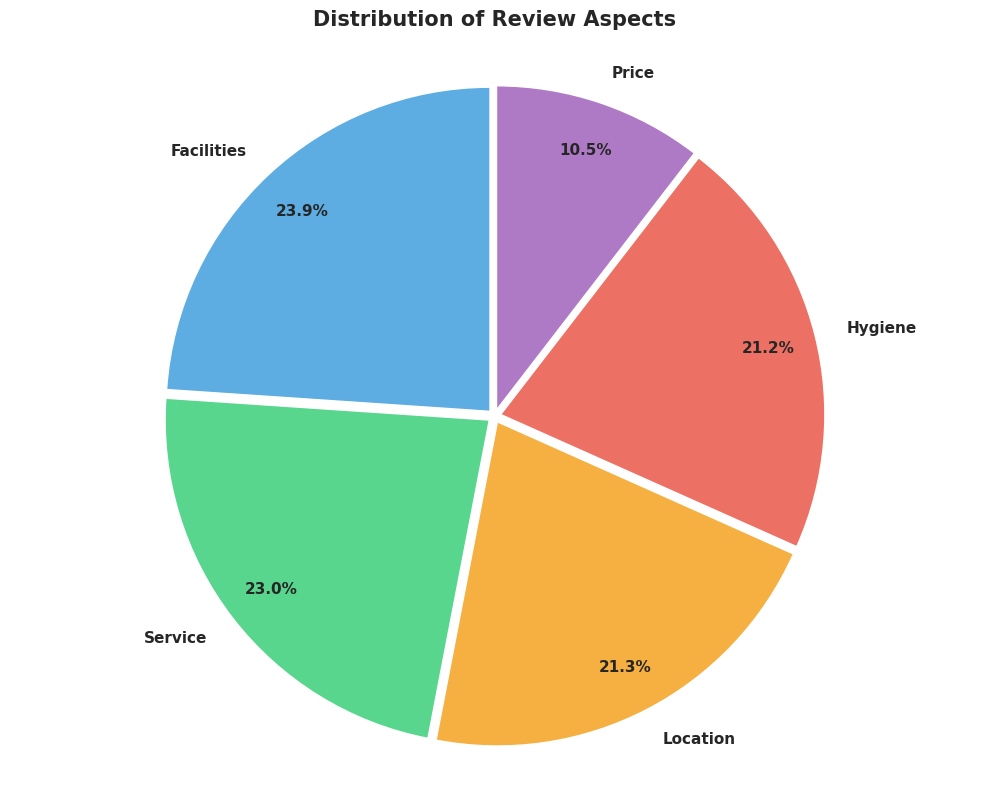

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 1. Định nghĩa khía cạnh
my_aspects = [
    'Location',
    'Service',
    'Price',
    'Facilities',
    'Hygiene'
]

aspect_mapping = {
    'Vị trí': 'Location',
    'Dịch vụ': 'Service',
    'Giá cả': 'Price',
    'Cơ sở vật chất': 'Facilities',
    'Vệ sinh': 'Hygiene'
}
aspect_counts = {a: 0 for a in my_aspects}

for label_str in df['Label'].astype(str):
    found = re.findall(r'\{(.*?)\}', label_str)
    for item in found:
        if '#' in item:
            asp = item.split('#')[0].strip()
            if asp in aspect_mapping:
                aspect_counts[aspect_mapping[asp]] += 1

s_aspects = pd.Series(aspect_counts).sort_values(ascending=False)

# 2. Vẽ biểu đồ Pie Chart
plt.figure(figsize=(10, 8), dpi=100) # Tăng độ phân giải

# Bảng màu hiện đại (Flat UI)
colors = ['#5dade2', '#58d68d', '#f5b041', '#ec7063', '#af7ac5']

# Vẽ biểu đồ tròn -
plt.pie(
    s_aspects,
    labels=s_aspects.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.85,
    explode=[0.02] * len(s_aspects),
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)

plt.title('Distribution of Review Aspects', fontsize=15, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

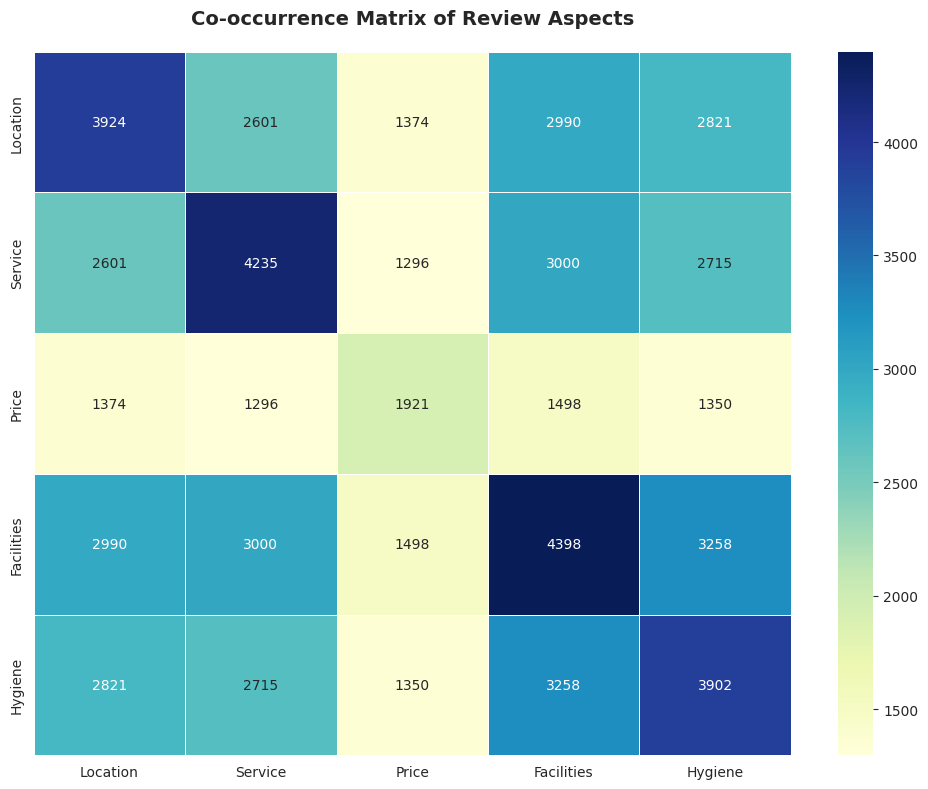

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import re

# 1. Tạo bảng dữ liệu nhị phân (0 và 1)
binary_data = []
aspects = ['Vị trí', 'Dịch vụ', 'Giá cả', 'Cơ sở vật chất', 'Vệ sinh']

for label_str in df['Label'].astype(str):
    row_presence = {a: 0 for a in aspects}
    found = re.findall(r'\{(.*?)\}', label_str)
    for item in found:
        if '#' in item:
            asp = item.split('#')[0].strip()
            if asp in row_presence:
                row_presence[asp] = 1
    binary_data.append(row_presence)

df_binary = pd.DataFrame(binary_data)

# 2. Tính ma trận số lượng xuất hiện đồng thời (Co-occurrence Matrix)
# Phép toán: df_binary.T (chuyển vị) nhân với df_binary
co_occurrence_matrix = df_binary.T.dot(df_binary)

# 3. Vẽ Heatmap với số lượng tuyệt đối
plt.figure(figsize=(10, 8))

# Thay đổi các tham số:
# fmt="d" để hiển thị số nguyên (integer)
# annot=True để hiện số lên ô
sns.heatmap(co_occurrence_matrix,
            annot=True,
            cmap='YlGnBu',
            fmt="d",
            linewidths=0.5)

plt.title('Co-occurrence Matrix of Review Aspects',
          fontsize=14, fontweight='bold', pad=20)
english_labels = [
    'Location',
    'Service',
    'Price',
    'Facilities',
    'Hygiene'
]

ax = plt.gca()
ax.set_xticklabels(english_labels, rotation=0)
ax.set_yticklabels(english_labels, rotation=90)
plt.tight_layout()
plt.show()

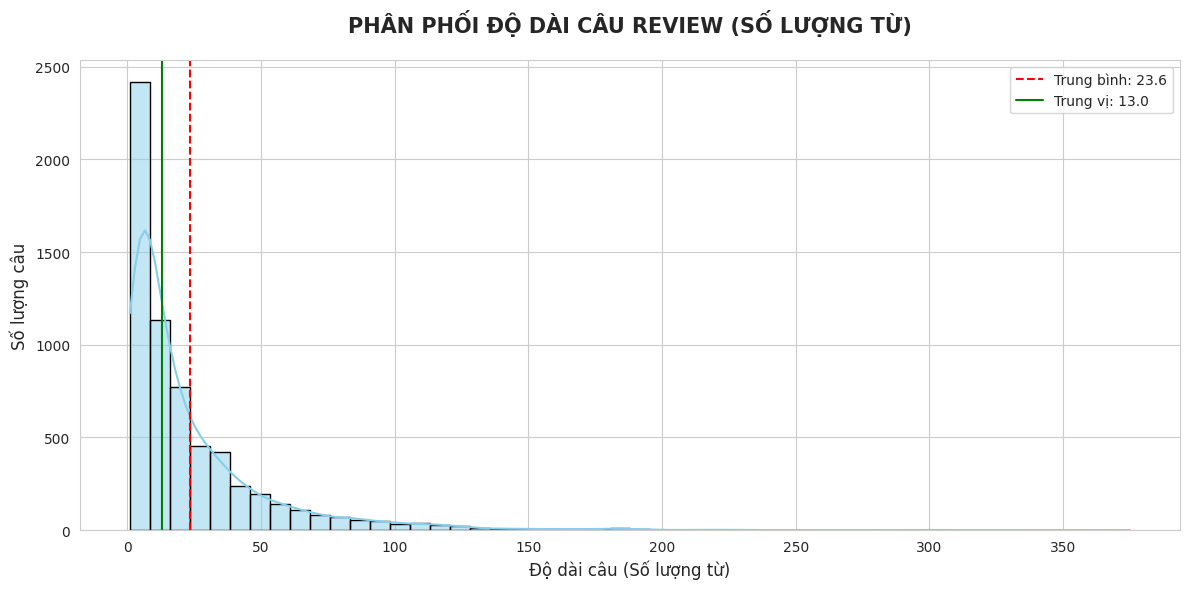

--- THỐNG KÊ ĐỘ DÀI ---
Câu ngắn nhất: 1 từ
Câu dài nhất: 375 từ
Độ dài trung bình: 23.57 từ
Số lượng câu có độ dài dưới 100 từ: 6164 câu


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tính độ dài của mỗi câu review (đếm số lượng từ)
df['Review_Length'] = df['Review_Final'].astype(str).apply(lambda x: len(x.split()))

# 2. Vẽ biểu đồ Histogram kết hợp đường KDE (đường cong mật độ)
plt.figure(figsize=(12, 6))
sns.histplot(df['Review_Length'], bins=50, kde=True, color='skyblue', edgecolor='black')

# Tính các thông số thống kê để vẽ đường đánh dấu
mean_len = df['Review_Length'].mean()
median_len = df['Review_Length'].median()
max_len = df['Review_Length'].max()

# Vẽ đường thẳng đánh dấu trung bình và trung vị
plt.axvline(mean_len, color='red', linestyle='--', label=f'Trung bình: {mean_len:.1f}')
plt.axvline(median_len, color='green', linestyle='-', label=f'Trung vị: {median_len:.1f}')

# Tinh chỉnh biểu đồ
plt.title('PHÂN PHỐI ĐỘ DÀI CÂU REVIEW (SỐ LƯỢNG TỪ)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Độ dài câu (Số lượng từ)', fontsize=12)
plt.ylabel('Số lượng câu', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

# 3. In ra các thông số để đưa vào bài viết
print(f"--- THỐNG KÊ ĐỘ DÀI ---")
print(f"Câu ngắn nhất: {df['Review_Length'].min()} từ")
print(f"Câu dài nhất: {max_len} từ")
print(f"Độ dài trung bình: {mean_len:.2f} từ")
print(f"Số lượng câu có độ dài dưới 100 từ: {len(df[df['Review_Length'] <= 100])} câu")